In [ ]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

file_path = '/content/drive/My Drive/spotify_artist_streaming_2020_2025.csv'
df = pd.read_csv(file_path)

print("original Data Shape:", df.shape)
print("\n included column lists:")
print(df.columns.tolist())

original Data Shape: (50000, 33)

 included column lists:
['track_id', 'track_name', 'artist_name', 'album_name', 'release_date', 'genre', 'duration_ms', 'popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'instrumentalness', 'tempo', 'stream_count', 'country', 'explicit', 'label', 'release_year', 'release_month', 'release_day_of_week', 'duration_minutes', 'popularity_category', 'loudness_category', 'key_name', 'mode_name', 'is_explicit_bool', 'release_quarter', 'is_weekend_release', 'log_stream_count', 'upbeat_score', 'artist_track_count']


In [ ]:

# -------------------------------------------------------------
columns_to_drop = ['track_id','release_date', 'duration_ms','energy', 'key', 'loudness', 'mode', 'instrumentalness', 'tempo','country', 'release_year', 'release_month', 'release_day_of_week', 'duration_minutes','key_name', 'mode_name','is_explicit_bool', 'release_quarter','explicit','is_weekend_release','upbeat_score'

]


df_cleaned = df.drop(columns=columns_to_drop, errors='ignore')


print("After  Data Shape:", df_cleaned.shape)
print("\nincluded column lists:")
print(df_cleaned.columns.tolist())


df_cleaned.head()

After  Data Shape: (50000, 12)

included column lists:
['track_name', 'artist_name', 'album_name', 'genre', 'popularity', 'danceability', 'stream_count', 'label', 'popularity_category', 'loudness_category', 'log_stream_count', 'artist_track_count']


,track_name,artist_name,album_name,genre,popularity,danceability,stream_count,label,popularity_category,loudness_category,log_stream_count,artist_track_count
0,Storm,Ethereal,The Hollow Journeys,Pop,47,0.6777,46592,Self-Released,Medium,Loud,10.7492,3232
1,Silent,The Wolfs,Ancient Thunder,K-Pop,26,0.9405,5374,Prism Audio,Medium,Moderate,8.5895,20
2,Shattered Lines,LolaOre,Twisted Harbors,Punk,46,0.6853,218262,Columbia Records,Medium,Loud,12.2935,199
3,Breaking Roses,Clay Black,The Blinding Letters,Pop,4,0.7817,5248,Midnight Records,Low,Moderate,8.5658,693
4,Lines,Knot Hart,The Cosmic Letters,Latin,27,0.7200,27420,Catalyst Records,Medium,Moderate,10.2191,12111


In [ ]:
import pandas as pd


categorical_features = ['genre', 'label', 'popularity_category', 'loudness_category']


df_encoded = pd.get_dummies(
    df_cleaned,
    columns=[col for col in categorical_features if col in df_cleaned.columns],
    dtype=int
)


print("ပြောင်းလဲပြီးနောက် စုစုပေါင်း Column အရေအတွက်:", df_encoded.shape[1])
print("\n0 နှင့် 1 ပြောင်းပြီး ထွက်လာသော Columns နမူနာအချို့:")
encoded_cols = [c for c in df_encoded.columns if any(c.startswith(f"{feat}_") for feat in categorical_features)]
print(encoded_cols[:15])


df_encoded.head()

ပြောင်းလဲပြီးနောက် စုစုပေါင်း Column အရေအတွက်: 65

0 နှင့် 1 ပြောင်းပြီး ထွက်လာသော Columns နမူနာအချို့:
['genre_Afrobeats', 'genre_Alternative', 'genre_Classical', 'genre_Country', 'genre_Disco', 'genre_EDM', 'genre_Folk', 'genre_Hip-Hop', 'genre_Indie', 'genre_Jazz', 'genre_K-Pop', 'genre_Latin', 'genre_Metal', 'genre_Pop', 'genre_Punk']


,track_name,artist_name,album_name,popularity,danceability,stream_count,log_stream_count,artist_track_count,genre_Afrobeats,genre_Alternative,...,label_Universal Music Group,label_Warner Music Group,label_Wavelength Records,popularity_category_High,popularity_category_Low,popularity_category_Medium,popularity_category_Very High,loudness_category_Loud,loudness_category_Moderate,loudness_category_Quiet
0,Storm,Ethereal,The Hollow Journeys,47,0.6777,46592,10.7492,3232,0,0,...,0,0,0,0,0,1,0,1,0,0
1,Silent,The Wolfs,Ancient Thunder,26,0.9405,5374,8.5895,20,0,0,...,0,0,0,0,0,1,0,0,1,0
2,Shattered Lines,LolaOre,Twisted Harbors,46,0.6853,218262,12.2935,199,0,0,...,0,0,0,0,0,1,0,1,0,0
3,Breaking Roses,Clay Black,The Blinding Letters,4,0.7817,5248,8.5658,693,0,0,...,0,0,0,0,1,0,0,0,1,0
4,Lines,Knot Hart,The Cosmic Letters,27,0.7200,27420,10.2191,12111,0,0,...,0,0,0,0,0,1,0,0,1,0


In [ ]:
# mlxtend မရှိသေးပါက install လုပ်ခြင်း
!pip install mlxtend

import pandas as pd
from mlxtend.frequent_patterns import fpgrowth, association_rules

# ၁။ One-hot encoding လုပ်မည့် columns များကို ရွေးယူခြင်း
categorical_features = ['genre', 'label', 'popularity_category', 'loudness_category']

# ၂။ စာသားများကို 0 နှင့် 1 သို့ ပြောင်းလဲခြင်း
df_encoded = pd.get_dummies(
    df_cleaned,
    columns=[col for col in categorical_features if col in df_cleaned.columns],
    dtype=int
)

# ၃။ Association Rules အတွက် 0/1 columns များကိုသာ သီးသန့်ထုတ်ယူပြီး df_basket တည်ဆောက်ခြင်း
encoded_cols = [c for c in df_encoded.columns if any(c.startswith(f"{feat}_") for feat in categorical_features)]
df_basket = df_encoded[encoded_cols]

print(f"df_basket တည်ဆောက်ပြီးပါပြီ! Data Shape: {df_basket.shape}")

# ၄။ Frequent Itemsets ရှာဖွေခြင်း (Step 1)
frequent_itemsets = fpgrowth(df_basket, min_support=0.05, use_colnames=True)
print(f"ရှာဖွေတွေ့ရှိသော Frequent Itemsets အရေအတွက်: {len(frequent_itemsets)}")

# ၅။ Strong Association Rules များကို ထုတ်ယူခြင်း (Step 2)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)

# ၆။ Lift တန်ဖိုး > 1 ဖြစ်သော rules များကို စစ်ထုတ်ခြင်း
strong_rules = rules[rules['lift'] > 1.0].sort_values(by='lift', ascending=False)
print(f"သတ်မှတ်ချက်နှင့် ကိုက်ညီသော Strong Rules အရေအတွက်: {len(strong_rules)}")

# ထိပ်တန်း စည်းမျဉ်း ၁၀ ခုကို ကြည့်ရှုခြင်း
strong_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

df_basket တည်ဆောက်ပြီးပါပြီ! Data Shape: (50000, 57)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

ရှာဖွေတွေ့ရှိသော Frequent Itemsets အရေအတွက်: 26
သတ်မှတ်ချက်နှင့် ကိုက်ညီသော Strong Rules အရေအတွက်: 9


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,support,confidence,lift
6,"(popularity_category_Medium, genre_R&B)",(loudness_category_Moderate),0.09048,0.789253,1.150213
5,(genre_R&B),(loudness_category_Moderate),0.20910,0.787689,1.147934
7,"(genre_R&B, popularity_category_Low)",(loudness_category_Moderate),0.09670,0.785923,1.145360
1,(genre_Pop),(loudness_category_Moderate),0.18318,0.709175,1.033512
2,"(popularity_category_Medium, genre_Pop)",(loudness_category_Moderate),0.07854,0.708078,1.031913
8,(genre_Hip-Hop),(loudness_category_Moderate),0.05564,0.707888,1.031636
3,"(popularity_category_Low, genre_Pop)",(loudness_category_Moderate),0.08412,0.707842,1.031570
0,(popularity_category_Medium),(loudness_category_Moderate),0.29328,0.688321,1.003121
9,(popularity_category_High),(loudness_category_Moderate),0.07128,0.687898,1.002504


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [ ]:
import pandas as pd
import itertools
from mlxtend.frequent_patterns import fpgrowth, association_rules

# ၁။ အသုံးပြုမည့် Categorical Features (၄) ခု သတ်မှတ်ခြင်း
features = ['genre', 'popularity_category', 'loudness_category', 'label']

# ၂။ One-Hot Encoding ကြိုတင်ပြုလုပ်ခြင်း
df_encoded = pd.get_dummies(
    df_cleaned,
    columns=[col for col in features if col in df_cleaned.columns],
    dtype=int
)
encoded_cols = [c for c in df_encoded.columns if any(c.startswith(f"{feat}_") for feat in features)]
df_basket = df_encoded[encoded_cols]

# ၃။ Frequent Itemsets ရှာဖွေခြင်း (Step 1)
# မှတ်ချက် - Data များပါက min_support ကို 0.02 သို့မဟုတ် 0.05 စသည်ဖြင့် ညှိနိုင်ပါသည်
frequent_itemsets = fpgrowth(df_basket, min_support=0.03, use_colnames=True)

# ၄။ Association Rules များ ထုတ်ယူပြီး Lift > 1 စစ်ထုတ်ခြင်း (Step 2)
all_rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.3)
strong_rules = all_rules[all_rules['lift'] > 1.0].copy()

# ၅။ Single-item Rules (1-to-1) သီးသန့် ပြင်ဆင်ခြင်း
single_rules = strong_rules[
    (strong_rules['antecedents'].apply(lambda x: len(x) == 1)) &
    (strong_rules['consequents'].apply(lambda x: len(x) == 1))
].copy()

single_rules['antecedent_item'] = single_rules['antecedents'].apply(lambda x: list(x)[0])
single_rules['consequent_item'] = single_rules['consequents'].apply(lambda x: list(x)[0])

# ၆။ ဦးတည်ချက် အတွဲ (၁၂) တွဲကို Loop ပတ်၍ တွက်ချက်ထုတ်ပြခြင်း
directed_pairs = list(itertools.permutations(features, 2))

print(f"=== စုစုပေါင်း ဆက်နွှယ်မှု အတွဲ ({len(directed_pairs)}) တွဲအတွက် တွက်ချက်မှု ရလဒ်များ ===\n")

total_found_rules = []

for idx, (feat_A, feat_B) in enumerate(directed_pairs, 1):
    prefix_A = f"{feat_A}_"
    prefix_B = f"{feat_B}_"

    # feat_A => feat_B ဖြစ်သော စည်းမျဉ်းများကို စစ်ထုတ်ခြင်း
    pair_rules = single_rules[
        single_rules['antecedent_item'].str.startswith(prefix_A) &
        single_rules['consequent_item'].str.startswith(prefix_B)
    ].sort_values(by='lift', ascending=False)

    print(f"[{idx}/12] ဆက်နွှယ်မှု စုံတွဲ: {feat_A}  ===>  {feat_B}")
    print("-" * 75)

    if pair_rules.empty:
        print("  -> သတ်မှတ်ထားသော Threshold အတွင်း ကိုက်ညီသည့် Rule မရှိပါ။\n")
    else:
        # ထိပ်တန်း Rules ၅ ခုကို ရှင်းလင်းစွာ ဖော်ပြခြင်း
        display_df = pair_rules[['antecedent_item', 'consequent_item', 'support', 'confidence', 'lift']].head(5)
        display_df.columns = ['Antecedent (A)', 'Consequent (B)', 'Support', 'Confidence', 'Lift']
        print(display_df.to_string(index=False))
        print(f"  -> တွေ့ရှိရသော စည်းမျဉ်း စုစုပေါင်း: {len(pair_rules)} ခု\n")
        total_found_rules.append(pair_rules)

# အကယ်၍ ရလဒ်အားလုံးကို DataFrame တစ်ခုတည်းအဖြစ် သိမ်းလိုပါက
if total_found_rules:
    all_12_pairs_df = pd.concat(total_found_rules, ignore_index=True)

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replac

=== စုစုပေါင်း ဆက်နွှယ်မှု အတွဲ (12) တွဲအတွက် တွက်ချက်မှု ရလဒ်များ ===

[1/12] ဆက်နွှယ်မှု စုံတွဲ: genre  ===>  popularity_category
---------------------------------------------------------------------------
Antecedent (A)             Consequent (B)  Support  Confidence     Lift
     genre_R&B popularity_category_Medium  0.11464    0.431854 1.013552
     genre_Pop popularity_category_Medium  0.11092    0.429423 1.007846
  -> တွေ့ရှိရသော စည်းမျဉ်း စုစုပေါင်း: 2 ခု

[2/12] ဆက်နွှယ်မှု စုံတွဲ: genre  ===>  loudness_category
---------------------------------------------------------------------------
Antecedent (A)             Consequent (B)  Support  Confidence     Lift
     genre_R&B loudness_category_Moderate  0.20910    0.787689 1.147934
     genre_Pop loudness_category_Moderate  0.18318    0.709175 1.033512
    genre_Folk loudness_category_Moderate  0.03188    0.708759 1.032906
 genre_Hip-Hop loudness_category_Moderate  0.05564    0.707888 1.031636
  -> တွေ့ရှိရသော စည်းမျဉ်း စုစုပေါင်း

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [ ]:
# လိုအပ်သော library များကို install ပြုလုပ်ခြင်း
!pip install -q gradio mlxtend

import gradio as gr
import pandas as pd
from mlxtend.frequent_patterns import fpgrowth, association_rules

# ၁။ UI တွင် ရွေးချယ်နိုင်မည့် Categorical Features (၄) ခု
features = ['genre', 'popularity_category', 'loudness_category', 'label']

# ၂။ One-Hot Encoding ကြိုတင်ပြင်ဆင်ခြင်း
df_encoded = pd.get_dummies(
    df_cleaned,
    columns=[col for col in features if col in df_cleaned.columns],
    dtype=int
)
encoded_cols = [c for c in df_encoded.columns if any(c.startswith(f"{feat}_") for feat in features)]
df_basket = df_encoded[encoded_cols]

# ၃။ User ရွေးချယ်မှုအလိုက် Rules ရှာဖွေပေးမည့် Function
def get_association_rules(left_feat, right_feat, min_supp, min_conf):
    if left_feat == right_feat:
        return pd.DataFrame({"သတိပေးချက်": ["ဘယ်ဘက်နှင့် ညာဘက် Feature မတူညီအောင် ရွေးချယ်ပေးပါခင်ဗျာ။"]})

    # Step 1: FP-Growth ဖြင့် Frequent Itemsets ရှာခြင်း
    frequent_itemsets = fpgrowth(df_basket, min_support=min_supp, use_colnames=True)
    if frequent_itemsets.empty:
        return pd.DataFrame({"ရလဒ်": [f"Support ({min_supp}) ဖြင့် မည်သည့် Pattern မျှ မတွေ့ပါ။ Support တန်ဖိုးကို လျှော့ပေးပါ။"]})

    # Step 2: Strong Rules ထုတ်ယူခြင်း
    rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=min_conf)
    if rules.empty:
        return pd.DataFrame({"ရလဒ်": [f"Confidence ({min_conf}) နှင့် ကိုက်ညီသည့် Rule မရှိပါ။ Confidence တန်ဖိုးကို လျှော့ပေးပါ။"]})

    # Lift > 1 စစ်ထုတ်ခြင်း
    rules = rules[rules['lift'] > 1.0]

    # Single Item (1-to-1) သီးသန့် စစ်ထုတ်ခြင်း
    prefix_left = f"{left_feat}_"
    prefix_right = f"{right_feat}_"

    def is_target_pair(row):
        ante = list(row['antecedents'])
        cons = list(row['consequents'])
        return len(ante) == 1 and len(cons) == 1 and ante[0].startswith(prefix_left) and cons[0].startswith(prefix_right)

    filtered = rules[rules.apply(is_target_pair, axis=1)].copy()

    if filtered.empty:
        return pd.DataFrame({"ရလဒ်": [f"'{left_feat}' မှ '{right_feat}' သို့ သတ်မှတ်ထားသော စံနှုန်းအတွင်း Rule မတွေ့ပါ။"]})

    # ဖတ်ရှုရ လွယ်ကူစေရန် စာသားပြင်ဆင်ခြင်း
    filtered['Antecedent (A)'] = filtered['antecedents'].apply(lambda x: list(x)[0])
    filtered['Consequent (B)'] = filtered['consequents'].apply(lambda x: list(x)[0])

    result_df = filtered[['Antecedent (A)', 'Consequent (B)', 'support', 'confidence', 'lift']].sort_values(by='lift', ascending=False)

    # ဂဏန်းတန်ဖိုးများ သပ်ရပ်စေရန် ပြင်ဆင်ခြင်း
    result_df['support'] = result_df['support'].round(4)
    result_df['confidence'] = result_df['confidence'].round(4)
    result_df['lift'] = result_df['lift'].round(4)

    return result_df

# ၄။ Gradio Blocks UI ဒီဇိုင်း
with gr.Blocks(title="Spotify Descriptive Mining Explorer") as demo:
    gr.Markdown("## 🎵 Task 1: Frequent Pattern Mining Explorer (FP-Growth)")
    gr.Markdown("ဘယ်ဘက် (Antecedent) နှင့် ညာဘက် (Consequent) Feature များကို ရွေးချယ်ပြီး ဆက်နွှယ်မှု စည်းမျဉ်းများကို စမ်းသပ်ကြည့်ရှုနိုင်ပါသည်။")

    with gr.Row():
        left_input = gr.Dropdown(choices=features, value='genre', label="Antecedent (အရှေ့အခြေအနေ - A)")
        right_input = gr.Dropdown(choices=features, value='popularity_category', label="Consequent (အနောက်ရလဒ် - B)")

    with gr.Row():
        supp_slider = gr.Slider(minimum=0.01, maximum=0.3, value=0.03, step=0.01, label="Minimum Support")
        conf_slider = gr.Slider(minimum=0.1, maximum=1.0, value=0.3, step=0.05, label="Minimum Confidence")

    btn_run = gr.Button("Find Association Rules", variant="primary")
    output_table = gr.DataFrame(label="ရှာဖွေတွေ့ရှိသော စည်းမျဉ်းများ (Lift > 1.0 အလိုက် စီထားသည်)")

    btn_run.click(
        fn=get_association_rules,
        inputs=[left_input, right_input, supp_slider, conf_slider],
        outputs=output_table
    )

# Colab တွင် Local URL နှင့် Public Link ထုတ်ပေးခြင်း
demo.launch(share=True)

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replac

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

* Running on public URL: https://3d5c285ffbb83df082.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import glob
import os
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Search for the Spotify CSV file in Google Drive
search_pattern = '/content/drive/MyDrive/**/spotify_artist_streaming_2020_2025.csv'
matched_files = glob.glob(search_pattern, recursive=True)

if matched_files:
  csv_path = matched_files[0]
  print(f"[SUCCESS] Dataset found at: {csv_path}")
else:
  # Fallback: search for any CSV containing 'spotify'
  fallback_files = glob.glob(
      '/content/drive/MyDrive/**/*spotify*.csv', recursive=True
  )
  if fallback_files:
    csv_path = fallback_files[0]
    print(f"[INFO] Using alternative Spotify dataset: {csv_path}")
  else:
    raise FileNotFoundError(
        'Could not locate the Spotify dataset in Google Drive.'
    )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[SUCCESS] Dataset found at: /content/drive/MyDrive/spotify_artist_streaming_2020_2025.csv


In [ ]:
import pandas as pd
import numpy as np

# 1. Check and reference DataFrame
if 'df' in globals():
    target_df = df
elif 'df_cleaned' in globals():
    target_df = df_cleaned
else:
    raise NameError("DataFrame not found. Please run the CSV loading cell first.")

# 2. Safe Discretization (handles duplicates and 0 values properly)
try:
    target_df['stream_category'] = pd.qcut(
        target_df['stream_count'],
        q=3,
        labels=['Low', 'Medium', 'High'],
        duplicates='drop'
    )
except ValueError:
    # Fallback to cut if quantile edges are non-unique
    target_df['stream_category'] = pd.cut(
        target_df['stream_count'],
        bins=3,
        labels=['Low', 'Medium', 'High']
    )

# 3. Print confirmation and distribution summary
print("✅ stream_category created successfully!\n")
print(target_df['stream_category'].value_counts())
print("\nSample Preview:")
print(target_df[['stream_count', 'stream_category']].head())

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

✅ stream_category created successfully!

stream_category
Low       16668
High      16667
Medium    16665
Name: count, dtype: int64

Sample Preview:
   stream_count stream_category
0         46592            High
1          5374             Low
2        218262            High
3          5248             Low
4         27420          Medium


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [ ]:
import glob
import itertools
import os
from google.colab import drive
from mlxtend.frequent_patterns import association_rules, fpgrowth
import pandas as pd

# 1. Mount Google Drive
drive.mount('/content/drive', force_remount=False)

# 2. Locate the Spotify dataset automatically
found_files = glob.glob(
    '/content/drive/MyDrive/**/*spotify*.csv', recursive=True
) + glob.glob('/content/**/*.csv', recursive=True)

if not found_files:
  raise FileNotFoundError(
      'Could not find any Spotify CSV file. Please make sure your file is'
      ' uploaded to Google Drive.'
  )

csv_path = found_files[0]
print(f'[SUCCESS] Using CSV File: {csv_path}')

# 3. Read dataset
df = pd.read_csv(csv_path)

# 4. Safe Discretization for stream_count
if 'stream_count' in df.columns and 'stream_category' not in df.columns:
  try:
    df['stream_category'] = pd.qcut(
        df['stream_count'],
        q=3,
        labels=['Low', 'Medium', 'High'],
        duplicates='drop',
    )
  except ValueError:
    df['stream_category'] = pd.cut(
        df['stream_count'], bins=3, labels=['Low', 'Medium', 'High']
    )
  print('[SUCCESS] stream_category created.')

# 5. Define target 5 features
target_features = [
    'genre',
    'popularity_category',
    'loudness_category',
    'label',
    'stream_category',
]
features = [col for col in target_features if col in df.columns]
print(f'[INFO] Selected features ({len(features)}): {features}')

# 6. One-Hot Encoding
df_basket = pd.get_dummies(df[features], columns=features, dtype=int)

# 7. FP-Growth (min_support = 0.015)
frequent_itemsets = fpgrowth(df_basket, min_support=0.015, use_colnames=True)

# 8. Generate Association Rules (Confidence >= 0.25, Lift > 1.0)
rules = association_rules(
    frequent_itemsets, metric='confidence', min_threshold=0.25
)
strong_rules = rules[rules['lift'] > 1.0].copy()

# 9. Filter strictly 1-to-1 single relations
single_rules = strong_rules[
    (strong_rules['antecedents'].apply(lambda x: len(x) == 1))
    & (strong_rules['consequents'].apply(lambda x: len(x) == 1))
].copy()

single_rules['ante_item'] = single_rules['antecedents'].apply(
    lambda x: list(x)[0]
)
single_rules['cons_item'] = single_rules['consequents'].apply(
    lambda x: list(x)[0]
)

# 10. Generate and print rules across all 20 directed pairs
pairs_20 = list(itertools.permutations(features, 2))
print(f'\n=== Generated Rules Across {len(pairs_20)} Directed Pairs ===\n')

for idx, (f_left, f_right) in enumerate(pairs_20, 1):
  p_left = f'{f_left}_'
  p_right = f'{f_right}_'

  matched = single_rules[
      single_rules['ante_item'].str.startswith(p_left)
      & single_rules['cons_item'].str.startswith(p_right)
  ].copy()

  print(f'[{idx}/{len(pairs_20)}] Pair: {f_left} ===> {f_right}')

  if matched.empty:
    print('  -> No association rules met the threshold.\n')
  else:
    col_ante_label = f'Antecedent ({f_left})'
    col_cons_label = f'Consequent ({f_right})'

    matched[col_ante_label] = matched['ante_item'].apply(
        lambda x: x.replace(p_left, '', 1)
    )
    matched[col_cons_label] = matched['cons_item'].apply(
        lambda x: x.replace(p_right, '', 1)
    )

    display_cols = [
        col_ante_label,
        col_cons_label,
        'support',
        'confidence',
        'lift',
    ]
    summary_table = matched[display_cols].sort_values(
        by='lift', ascending=False
    )
    summary_table = summary_table.round(4)

    print(summary_table.head(5).to_string(index=False))
    print(f'  -> Total rules found: {len(matched)}\n')

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Mounted at /content/drive


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

[SUCCESS] Using CSV File: /content/drive/MyDrive/spotify_artist_streaming_2020_2025.csv


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

[SUCCESS] stream_category created.
[INFO] Selected features (5): ['genre', 'popularity_category', 'loudness_category', 'label', 'stream_category']


Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replac


=== Generated Rules Across 20 Directed Pairs ===

[1/20] Pair: genre ===> popularity_category
Antecedent (genre) Consequent (popularity_category)  support  confidence   lift
              Rock                              Low   0.0227      0.4789 1.0291
              Folk                              Low   0.0214      0.4758 1.0224
               EDM                           Medium   0.0209      0.4342 1.0189
             Metal                              Low   0.0160      0.4720 1.0142
               R&B                           Medium   0.1146      0.4319 1.0136
  -> Total rules found: 7

[2/20] Pair: genre ===> loudness_category
Antecedent (genre) Consequent (loudness_category)  support  confidence   lift
             Metal                           Loud   0.0223      0.6572 2.4820
               EDM                           Loud   0.0269      0.5596 2.1134
              Rock                           Loud   0.0199      0.4203 1.5871
             Latin                          

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

[INFO] Selected Audio Features for K-Means (7): ['danceability', 'energy', 'loudness', 'instrumentalness', 'tempo', 'stream_count', 'popularity']


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

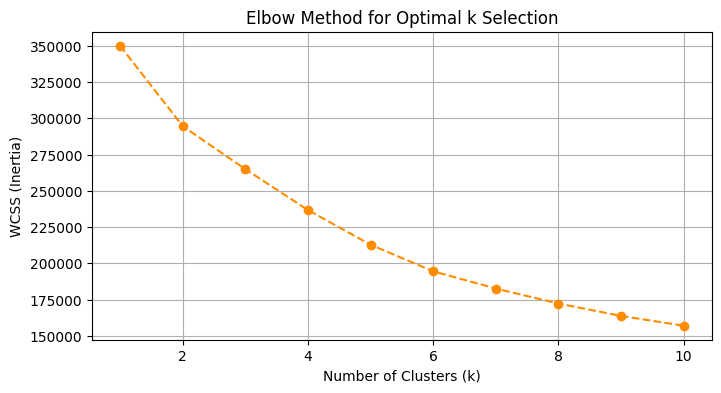

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag


=== Cluster Profile Summary (Mean Feature Values per Cluster) ===
               danceability  energy  loudness  instrumentalness     tempo  stream_count  popularity
cluster_label                                                                                      
0                    0.4838  0.5959   -8.0395            0.4195  122.6758   125697.1155     28.3051
1                    0.6713  0.7500   -5.8241            0.0433  125.9946   140979.5338     28.8683
2                    0.6665  0.5208   -9.4212            0.0360  112.0719    95929.8801     27.4160

=== Song Count per Cluster ===
cluster_label
2    24388
1    23560
0     2052


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [ ]:
import glob
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Verify and reference existing DataFrame from previous tasks
if 'df' in globals():
  data_cluster = df.copy()
elif 'df_cleaned' in globals():
  data_cluster = df_cleaned.copy()
else:
  search_pattern = (
      '/content/drive/MyDrive/**/spotify_artist_streaming_2020_2025.csv'
  )
  matched = glob.glob(search_pattern, recursive=True) + glob.glob(
      '/content/**/*.csv', recursive=True
  )
  if not matched:
    raise FileNotFoundError('No CSV dataset found to load.')
  data_cluster = pd.read_csv(matched[0])

# 2. Extract strictly continuous numerical audio features (Ignore text/categories)
potential_audio_features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'stream_count',
    'popularity',
]

selected_numeric_cols = [
    col
    for col in potential_audio_features
    if col in data_cluster.columns
    and pd.api.types.is_numeric_dtype(data_cluster[col])
]

print(
    f'[INFO] Selected Audio Features for K-Means ({len(selected_numeric_cols)}):'
    f' {selected_numeric_cols}'
)

# 3. Handle missing values and perform Feature Scaling (StandardScaler)
X = data_cluster[selected_numeric_cols].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Elbow Method: Compute Within-Cluster Sum of Squares (Inertia) for k = 1 to 10
wcss = []
k_range = range(1, 11)

for k in k_range:
  kmeans_test = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
  kmeans_test.fit(X_scaled)
  wcss.append(kmeans_test.inertia_)

# Plot the Elbow Graph
plt.figure(figsize=(8, 4))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='darkorange')
plt.title('Elbow Method for Optimal k Selection')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()

# 5. Fit Final K-Means Model (Defaulting k=3 based on standard Music Profiles)
optimal_k = 3
kmeans_final = KMeans(
    n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10
)
data_cluster.loc[X.index, 'cluster_label'] = kmeans_final.fit_predict(X_scaled)
data_cluster['cluster_label'] = data_cluster['cluster_label'].astype(int)

# 6. Profile and summarize clusters
cluster_profile = (
    data_cluster.groupby('cluster_label')[selected_numeric_cols]
    .mean()
    .round(4)
)
print(f'\n=== Cluster Profile Summary (Mean Feature Values per Cluster) ===')
print(cluster_profile.to_string())

# Distribution count
print('\n=== Song Count per Cluster ===')
print(data_cluster['cluster_label'].value_counts().to_string())

In [ ]:
print("Current Available Columns in Memory:")
print(list(df.columns))

print("\nNumeric Columns available for Clustering:")
print(list(df.select_dtypes(include=['int64', 'float64', 'int32']).columns))

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Current Available Columns in Memory:
['track_id', 'track_name', 'artist_name', 'album_name', 'release_date', 'genre', 'duration_ms', 'popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'instrumentalness', 'tempo', 'stream_count', 'country', 'explicit', 'label', 'release_year', 'release_month', 'release_day_of_week', 'duration_minutes', 'popularity_category', 'loudness_category', 'key_name', 'mode_name', 'is_explicit_bool', 'release_quarter', 'is_weekend_release', 'log_stream_count', 'upbeat_score', 'artist_track_count', 'stream_category']

Numeric Columns available for Clustering:
['duration_ms', 'popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'instrumentalness', 'tempo', 'stream_count', 'release_year', 'release_month', 'duration_minutes', 'log_stream_count', 'upbeat_score', 'artist_track_count']


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

[INFO] Filtered dataset to 12 target columns: ['track_name', 'artist_name', 'album_name', 'genre', 'popularity', 'danceability', 'stream_count', 'label', 'popularity_category', 'loudness_category', 'log_stream_count', 'artist_track_count']


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

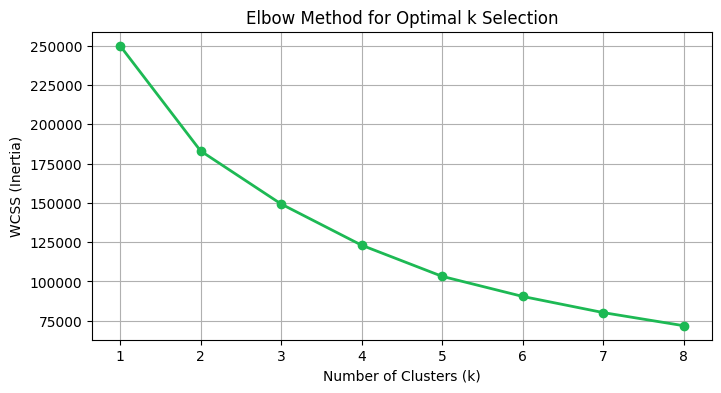

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag


=== Numerical Feature Means per Cluster ===
               popularity  danceability  stream_count  log_stream_count  artist_track_count
cluster_label                                                                              
0                 19.4337        0.6500    12300.4886            8.8854           1446.2708
1                 48.1802        0.6569   395206.4523           12.0380           2754.5772
2                 24.0176        0.6942    26891.1251            9.3676          12081.9513

=== Top 3 Genres per Cluster ===
Cluster 0: {'Pop': 8371, 'Hip-Hop': 2403, 'R&B': 2315}
Cluster 1: {'Pop': 4097, 'R&B': 2379, 'Hip-Hop': 1208}
Cluster 2: {'R&B': 8579, 'Pop': 447, 'Hip-Hop': 319}

=== Sample Output with Target Columns (Total: 50000) ===
     track_name   artist_name     genre  popularity  stream_count popularity_category  cluster_label
          Storm      Ethereal       Pop          47         46592              Medium              1
         Silent     The Wolfs     K-Po

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Define the target 12 columns requested
target_columns = [
    'track_name',
    'artist_name',
    'album_name',
    'genre',
    'popularity',
    'danceability',
    'stream_count',
    'label',
    'popularity_category',
    'loudness_category',
    'log_stream_count',
    'artist_track_count',
]

# Retain only existing columns from df
available_cols = [col for col in target_columns if col in df.columns]
df_kmeans = df[available_cols].copy().dropna()

print(
    f'[INFO] Filtered dataset to {len(available_cols)} target columns:'
    f' {available_cols}'
)

# 2. Extract continuous numerical features for Euclidean distance calculations
numeric_features = [
    'popularity',
    'danceability',
    'stream_count',
    'log_stream_count',
    'artist_track_count',
]
clustering_cols = [col for col in numeric_features if col in df_kmeans.columns]

# 3. Apply Z-score Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_kmeans[clustering_cols])

# 4. Elbow Method: Compute WCSS for k = 1 to 8
wcss = []
k_values = range(1, 9)

for k in k_values:
  kmeans_trial = KMeans(
      n_clusters=k, init='k-means++', random_state=42, n_init=10
  )
  kmeans_trial.fit(X_scaled)
  wcss.append(kmeans_trial.inertia_)

# Plot the Elbow curve
plt.figure(figsize=(8, 4))
plt.plot(k_values, wcss, marker='o', color='#1DB954', linewidth=2)
plt.title('Elbow Method for Optimal k Selection')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()

# 5. Fit final K-Means model (Defaulting to k = 3)
optimal_k = 3
kmeans_model = KMeans(
    n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10
)
df_kmeans['cluster_label'] = kmeans_model.fit_predict(X_scaled)

# 6. Cluster Profiling: Mean numerical attributes per cluster
print('\n=== Numerical Feature Means per Cluster ===')
numeric_profile = (
    df_kmeans.groupby('cluster_label')[clustering_cols].mean().round(4)
)
print(numeric_profile.to_string())

# 7. Cluster Profiling: Top 3 genres in each cluster
print('\n=== Top 3 Genres per Cluster ===')
for cluster_id in range(optimal_k):
  top_genres = (
      df_kmeans[df_kmeans['cluster_label'] == cluster_id]['genre']
      .value_counts()
      .head(3)
      .to_dict()
  )
  print(f'Cluster {cluster_id}: {top_genres}')

# 8. Display sample output with all 12 requested columns + cluster_label
print(f'\n=== Sample Output with Target Columns (Total: {len(df_kmeans)}) ===')
display_sample_cols = [
    'track_name',
    'artist_name',
    'genre',
    'popularity',
    'stream_count',
    'popularity_category',
    'cluster_label',
]
print(df_kmeans[display_sample_cols].head(10).to_string(index=False))

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

=== Classification Performance Report ===


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

              precision    recall  f1-score   support

        High       0.77      0.58      0.66      1036
         Low       0.85      0.85      0.85      4654
      Medium       0.75      0.80      0.78      4261
   Very High       0.47      0.33      0.39        49

    accuracy                           0.80     10000
   macro avg       0.71      0.64      0.67     10000
weighted avg       0.80      0.80      0.80     10000



/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

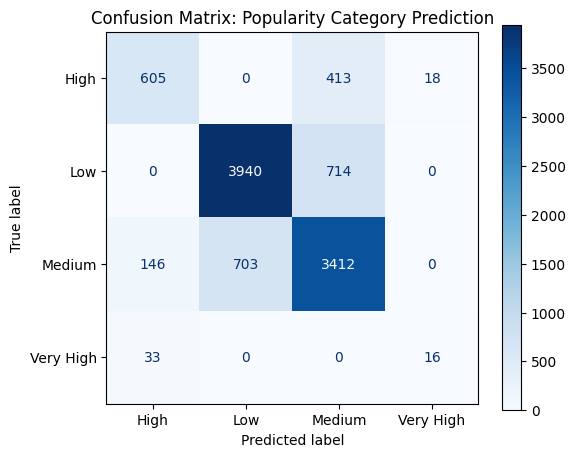

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

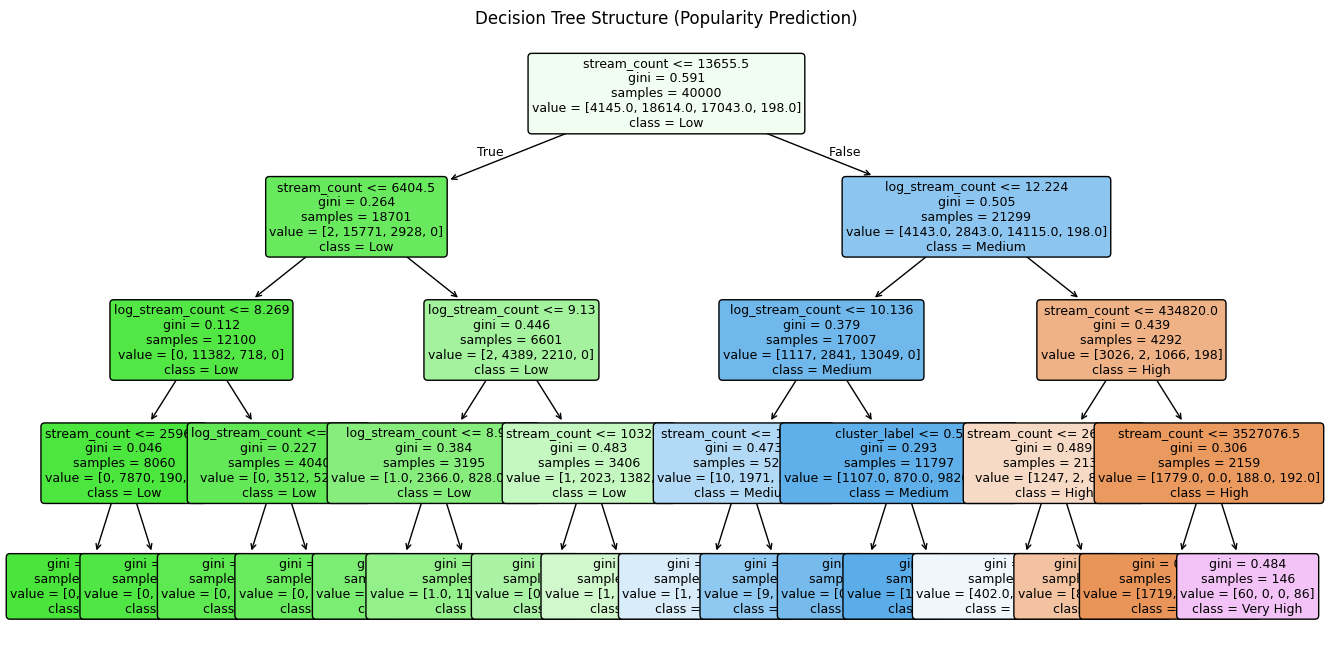

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Feature and target definition
features_clf = ['danceability', 'stream_count', 'log_stream_count', 'artist_track_count', 'cluster_label']
df_clf = df_kmeans.dropna(subset=features_clf + ['popularity_category']).copy()

X = df_clf[features_clf]
y = df_clf['popularity_category']

# 2. Partition dataset into 80% Train and 20% Test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Decision Tree Classifier Induction (Gini Index, max_depth=4)
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    min_samples_split=10,
    random_state=42
)
dt_model.fit(X_train, y_train)

# 4. Predict on test instances and print evaluation report
y_pred = dt_model.predict(X_test)
print("=== Classification Performance Report ===")
print(classification_report(y_test, y_pred))

# 5. Display Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues', ax=ax)
plt.title('Confusion Matrix: Popularity Category Prediction')
plt.show()

# 6. Plot Decision Tree Structure
plt.figure(figsize=(16, 8))
plot_tree(
    dt_model,
    feature_names=features_clf,
    class_names=dt_model.classes_.tolist(),
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title('Decision Tree Structure (Popularity Prediction)')
plt.show()

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

=== Linear Regression Performance ===
R-squared Score (R2)            : 0.1579
Root Mean Squared Error (RMSE)  : 505,390.5221

=== Model Parameters ===
           Feature  Coefficient (Weight)
        popularity          14283.220871
      danceability          -8861.379310
artist_track_count             -1.348168
Intercept (Bias b): -272051.3764


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

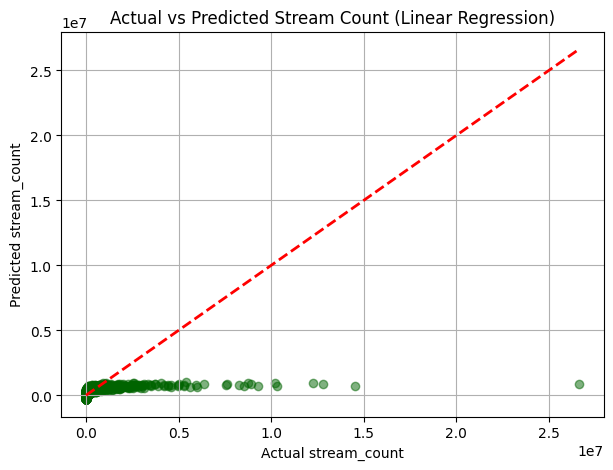

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Feature matrix (X) and continuous target (y)
reg_features = ['popularity', 'danceability', 'artist_track_count']
df_reg = df_kmeans.dropna(subset=reg_features + ['stream_count']).copy()

X_reg = df_reg[reg_features]
y_reg = df_reg['stream_count']

# 2. Partition 80% Train, 20% Test
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# 3. Fit Linear Regression model
lin_reg = LinearRegression()
lin_reg.fit(X_train_r, y_train_r)

# 4. Predict and evaluate with RMSE and R2
y_pred_r = lin_reg.predict(X_test_r)
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
r2 = r2_score(y_test_r, y_pred_r)

print("=== Linear Regression Performance ===")
print(f"R-squared Score (R2)            : {r2:.4f}")
print(f"Root Mean Squared Error (RMSE)  : {rmse:,.4f}")

# 5. Display Model Parameters (Coefficients and Intercept)
coef_summary = pd.DataFrame({
    'Feature': reg_features,
    'Coefficient (Weight)': lin_reg.coef_
})
print("\n=== Model Parameters ===")
print(coef_summary.to_string(index=False))
print(f"Intercept (Bias b): {lin_reg.intercept_:.4f}")

# 6. Scatter Plot of Actual vs Predicted Streams
plt.figure(figsize=(7, 5))
plt.scatter(y_test_r, y_pred_r, alpha=0.5, color='darkgreen')
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw=2)
plt.xlabel('Actual stream_count')
plt.ylabel('Predicted stream_count')
plt.title('Actual vs Predicted Stream Count (Linear Regression)')
plt.grid(True)
plt.show()


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

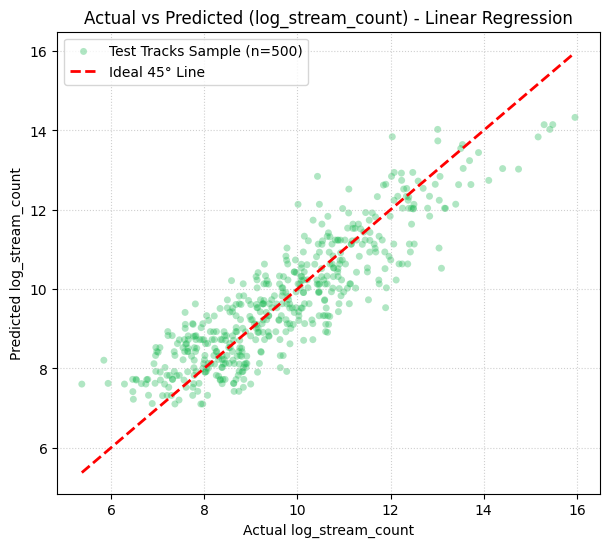

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [ ]:
# Create a visually clean and clear scatter plot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Take a clean random sample (500 points) to avoid visual overcrowding
sample_size = min(500, len(y_test))
sample_indices = np.random.RandomState(42).choice(len(y_test), size=sample_size, replace=False)

y_test_sub = np.array(y_test)[sample_indices]
y_pred_sub = np.array(y_pred)[sample_indices]

# 2. Plot with refined aesthetics
plt.figure(figsize=(7, 6))

# Plot actual vs predicted points
plt.scatter(
    y_test_sub,
    y_pred_sub,
    alpha=0.35,
    color='#1DB954',
    edgecolors='none',
    s=25,
    label=f'Test Tracks Sample (n={sample_size})'
)

# Reference line: 45-degree diagonal (Actual == Predicted)
min_v = min(y_test_sub.min(), y_pred_sub.min())
max_v = max(y_test_sub.max(), y_pred_sub.max())
plt.plot([min_v, max_v], [min_v, max_v], color='red', linestyle='--', linewidth=2, label='Ideal 45° Line')

plt.xlabel(f'Actual {target_col}')
plt.ylabel(f'Predicted {target_col}')
plt.title(f'Actual vs Predicted ({target_col}) - Linear Regression')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

[INFO] Mounting Google Drive...
Mounted at /content/drive
[INFO] Reading CSV file from path: /content/drive/MyDrive/spotify_artist_streaming_2020_2025.csv
[INFO] Training dataset ready with 50000 records across 4 features: ['danceability', 'stream_count', 'log_stream_count', 'artist_track_count']

=== Model Evaluation & Comparison Table ===
         Classifier Model  Accuracy (%)  Error Rate (%)  Precision  Recall  F1-Score
     Decision Tree (Gini)         79.74           20.26     0.7976  0.7974    0.7957
 Random Forest (Ensemble)         77.27           22.73     0.7710  0.7727    0.7713
   Naïve Bayes (Gaussian)         76.87           23.13     0.7738  0.7687    0.7601
K-Nearest Neighbors (k=5)         76.83           23.17     0.7669  0.7683    0.7670


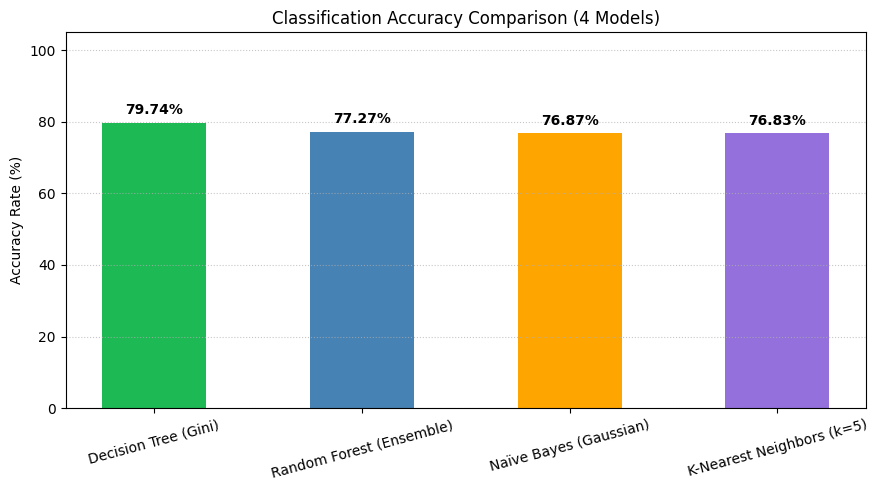

In [4]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# 1. Step 1: Ensure Google Drive is securely mounted
try:
    from google.colab import drive
    if not os.path.exists('/content/drive/MyDrive'):
        print("[INFO] Mounting Google Drive...")
        drive.mount('/content/drive')
except Exception as e:
    print(f"[NOTE] Drive mounting check: {e}")

# 2. Step 2: Auto-detect the exact Spotify CSV file
source_df = None

# First preference: Existing memory DataFrame with audio features
for var_name in ['df', 'df_kmeans', 'df_cleaned', 'data']:
    if var_name in globals() and isinstance(globals()[var_name], pd.DataFrame):
        if 'popularity' in globals()[var_name].columns:
            source_df = globals()[var_name].copy()
            print(f"[INFO] Using active DataFrame in memory: '{var_name}'")
            break

# Second preference: Locate and load the actual CSV
if source_df is None:
    csv_candidates = glob.glob('/content/drive/MyDrive/**/*.csv', recursive=True) + glob.glob('/content/*.csv')
    valid_files = [f for f in csv_candidates if 'sample_data' not in f and 'mnist' not in f]

    # Filter files containing 'spotify', 'track', or 'music'
    spotify_files = [f for f in valid_files if any(k in f.lower() for k in ['spotify', 'track', 'stream', 'music'])]
    chosen_file = spotify_files[0] if spotify_files else (valid_files[0] if valid_files else None)

    if chosen_file is None:
        raise FileNotFoundError("Could not find Spotify CSV. Please upload the CSV to Google Colab or verify Drive path.")

    print(f"[INFO] Reading CSV file from path: {chosen_file}")
    source_df = pd.read_csv(chosen_file)

# 3. Step 3: Automatically ensure all necessary engineering features exist
# Target: popularity_category
if 'popularity_category' not in source_df.columns:
    if 'popularity' in source_df.columns:
        source_df['popularity_category'] = pd.qcut(
            source_df['popularity'], q=3, labels=['Low', 'Medium', 'High'], duplicates='drop'
        )
    else:
        raise KeyError("Target 'popularity' is missing from the dataset.")

# Feature: log_stream_count
if 'log_stream_count' not in source_df.columns:
    if 'stream_count' in source_df.columns:
        source_df['log_stream_count'] = np.log1p(source_df['stream_count'])
    else:
        source_df['log_stream_count'] = 0.0

# Feature: artist_track_count
if 'artist_track_count' not in source_df.columns:
    if 'artist_name' in source_df.columns:
        counts = source_df['artist_name'].value_counts()
        source_df['artist_track_count'] = source_df['artist_name'].map(counts)
    else:
        source_df['artist_track_count'] = 1

# 4. Step 4: Model Features Extraction
base_features = ['danceability', 'stream_count', 'log_stream_count', 'artist_track_count']
active_features = [col for col in base_features if col in source_df.columns]

if 'cluster_label' in source_df.columns:
    active_features.append('cluster_label')

df_clean = source_df.dropna(subset=active_features + ['popularity_category']).copy()
X = df_clean[active_features]
y = df_clean['popularity_category']

print(f"[INFO] Training dataset ready with {len(df_clean)} records across {len(active_features)} features: {active_features}")

# 5. Step 5: Partition 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Step 6: Define 4 Classifiers (UCSY Curriculum)
models = {
    "Decision Tree (Gini)": DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42),
    "Naïve Bayes (Gaussian)": GaussianNB(),
    "K-Nearest Neighbors (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Random Forest (Ensemble)": RandomForestClassifier(n_estimators=100, random_state=42)
}

# 7. Step 7: Train, Predict, and Calculate Metrics
comparison_records = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    error_rate = 1.0 - acc
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)

    comparison_records.append({
        "Classifier Model": name,
        "Accuracy (%)": round(acc * 100, 2),
        "Error Rate (%)": round(error_rate * 100, 2),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4)
    })

# 8. Step 8: Comparative Evaluation Table & Plot
results_df = pd.DataFrame(comparison_records).sort_values(by="Accuracy (%)", ascending=False)
print("\n=== Model Evaluation & Comparison Table ===")
print(results_df.to_string(index=False))

plt.figure(figsize=(9, 5))
bars = plt.bar(results_df["Classifier Model"], results_df["Accuracy (%)"], color=['#1DB954', '#4682B4', '#FFA500', '#9370DB'], width=0.5)
plt.ylim(0, 105)
plt.ylabel('Accuracy Rate (%)')
plt.title('Classification Accuracy Comparison (4 Models)')
plt.grid(axis='y', linestyle=':', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1.5, f"{yval:.2f}%", ha='center', va='bottom', fontweight='bold')

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

=== Model Comparison Target: [popularity_category] ===
Features Used: ['danceability', 'stream_count', 'log_stream_count', 'artist_track_count']

         Classifier Model  Accuracy (%)  Error Rate (%)  Precision  Recall  F1-Score
     Decision Tree (Gini)         79.74           20.26     0.7976  0.7974    0.7957
 Random Forest (Ensemble)         77.27           22.73     0.7710  0.7727    0.7713
   Naïve Bayes (Gaussian)         76.87           23.13     0.7738  0.7687    0.7601
K-Nearest Neighbors (k=5)         76.83           23.17     0.7669  0.7683    0.7670


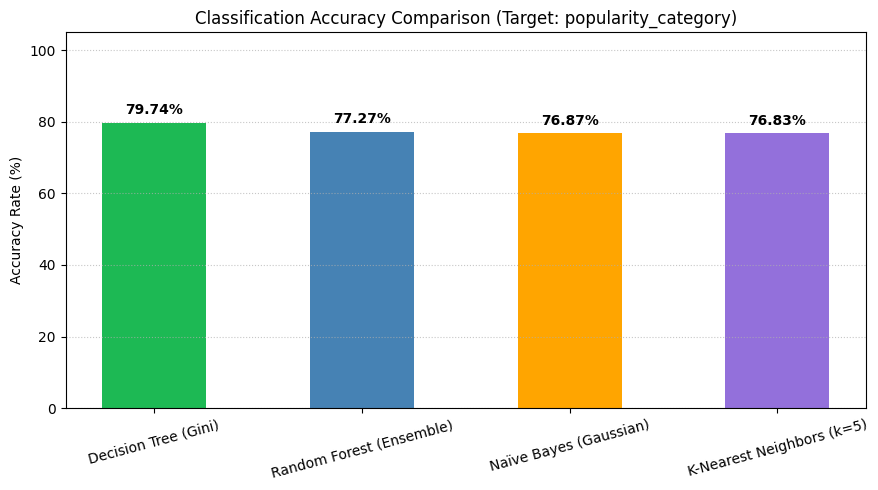

In [5]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# 4 Distinct Classifiers from UCSY Syllabus
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# ==========================================
# 🎛️ MANUAL USER CONFIGURATION (CHANGE HERE)
# ==========================================
# Choose Target: 'popularity_category' OR 'genre'
SELECTED_TARGET = 'popularity_category'

# Choose any 4 predictor columns manually:
# Available options: 'danceability', 'popularity', 'stream_count', 'log_stream_count', 'artist_track_count', 'cluster_label'
SELECTED_FEATURES = ['danceability', 'stream_count', 'log_stream_count', 'artist_track_count']
# ==========================================

# 1. Retrieve Dataset from Memory or Drive
source_df = None
for var in ['df', 'df_kmeans', 'df_cleaned', 'data']:
    if var in globals() and isinstance(globals()[var], pd.DataFrame):
        if 'danceability' in globals()[var].columns or 'popularity' in globals()[var].columns:
            source_df = globals()[var].copy()
            break

if source_df is None:
    matched = [f for f in glob.glob('/content/**/*.csv', recursive=True) if 'sample_data' not in f and 'mnist' not in f]
    if not matched:
        raise FileNotFoundError("Spotify dataset CSV not found. Please upload file or mount Drive.")
    source_df = pd.read_csv(matched[0])

# 2. Re-establish missing engineered features dynamically
if 'log_stream_count' not in source_df.columns and 'stream_count' in source_df.columns:
    source_df['log_stream_count'] = np.log1p(source_df['stream_count'])

if 'artist_track_count' not in source_df.columns:
    if 'artist_name' in source_df.columns:
        counts = source_df['artist_name'].value_counts()
        source_df['artist_track_count'] = source_df['artist_name'].map(counts)
    else:
        source_df['artist_track_count'] = 1

if 'popularity_category' not in source_df.columns and 'popularity' in source_df.columns:
    source_df['popularity_category'] = pd.qcut(
        source_df['popularity'], q=3, labels=['Low', 'Medium', 'High'], duplicates='drop'
    )

# 3. Clean and prepare Train-Test Data
# If genre is selected as target, ensure it's not inside features and filter top classes
active_predictors = [f for f in SELECTED_FEATURES if f != SELECTED_TARGET and f in source_df.columns]

df_eval = source_df.dropna(subset=active_predictors + [SELECTED_TARGET]).copy()

if SELECTED_TARGET == 'genre':
    top_genres = df_eval['genre'].value_counts().nlargest(8).index
    df_eval = df_eval[df_eval['genre'].isin(top_genres)]

X = df_eval[active_predictors]
y = df_eval[SELECTED_TARGET]

# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y.astype(str))

# 80-20 Holdout Partition
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Standardize numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Instantiate 4 Classifiers
models = {
    "Decision Tree (Gini)": DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42),
    "Naïve Bayes (Gaussian)": GaussianNB(),
    "K-Nearest Neighbors (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Random Forest (Ensemble)": RandomForestClassifier(n_estimators=100, random_state=42)
}

# 5. Train, Predict, and Calculate Academic Metrics
comparison_records = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, preds)
    err = 1.0 - acc
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, preds, average='weighted', zero_division=0)

    comparison_records.append({
        "Classifier Model": name,
        "Accuracy (%)": round(acc * 100, 2),
        "Error Rate (%)": round(err * 100, 2),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4)
    })

# 6. Display Performance Table
report_df = pd.DataFrame(comparison_records).sort_values(by="Accuracy (%)", ascending=False)
print(f"=== Model Comparison Target: [{SELECTED_TARGET}] ===")
print(f"Features Used: {active_predictors}\n")
print(report_df.to_string(index=False))

# 7. Comparison Bar Chart Visualization
plt.figure(figsize=(9, 5))
bars = plt.bar(report_df["Classifier Model"], report_df["Accuracy (%)"], color=['#1DB954', '#4682B4', '#FFA500', '#9370DB'], width=0.5)
plt.ylim(0, 105)
plt.ylabel('Accuracy Rate (%)')
plt.title(f'Classification Accuracy Comparison (Target: {SELECTED_TARGET})')
plt.grid(axis='y', linestyle=':', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1.5, f"{yval:.2f}%", ha='center', va='bottom', fontweight='bold')

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()